In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# First Look

In [2]:
df = pd.read_csv('../data/raw/INMATE_ACTIVE_ROOT.txt', sep='\t', encoding='latin-1')
df.head()

,DCNumber,LastName,FirstName,MiddleName,NameSuffix,Race,Sex,BirthDate,PrisonReleaseDate,ReceiptDate,releasedateflag_descr,race_descr,custody_description,FACILITY_description
0,000132,TELFAIR,MICHAEL,NaN,NaN,B,M,12/04/1967,01/27/2033,10/08/2018,valid release date,BLACK,MINIMUM,MADISON C.I.
1,000155,LOCKETT,JERRY,I,NaN,B,M,09/26/1985,05/14/2026,05/23/2024,valid release date,BLACK,MEDIUM,GULF C.I.
2,000175,ELMORE,CHAD,R,NaN,W,M,10/20/1982,07/20/2028,06/11/2025,valid release date,WHITE,CLOSE,JACKSON C.I.
3,000191,CARRILLO,ISAIAS,NaN,JR,W,M,02/21/1998,03/30/2028,09/24/2025,valid release date,WHITE,MEDIUM,APALACHEE EAST UNIT
4,000203,RHINESMITH,AUSTIN,A,NaN,W,M,09/12/2000,09/06/2027,07/24/2025,valid release date,WHITE,MEDIUM,CFRC-EAST


In [3]:
df.shape

(90663, 14)

In [4]:
df.dtypes

DCNumber                 object
LastName                 object
FirstName                object
MiddleName               object
NameSuffix               object
Race                     object
Sex                      object
BirthDate                object
PrisonReleaseDate        object
ReceiptDate              object
releasedateflag_descr    object
race_descr               object
custody_description      object
FACILITY_description     object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90663 entries, 0 to 90662
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   DCNumber               90663 non-null  object
 1   LastName               90662 non-null  object
 2   FirstName              90663 non-null  object
 3   MiddleName             69042 non-null  object
 4   NameSuffix             7413 non-null   object
 5   Race                   90663 non-null  object
 6   Sex                    90663 non-null  object
 7   BirthDate              90663 non-null  object
 8   PrisonReleaseDate      74745 non-null  object
 9   ReceiptDate            90663 non-null  object
 10  releasedateflag_descr  90663 non-null  object
 11  race_descr             90663 non-null  object
 12  custody_description    88358 non-null  object
 13  FACILITY_description   90663 non-null  object
dtypes: object(14)
memory usage: 9.7+ MB


# Missing Values

The heatmap below visualizes missing data across the dataset. Each column is represented on the x-axis, and each row in the dataset is represented on the y-axis. **Black indicates no missing value, white indicates a missing value.**

From the heatmap we can observe which columns have missing data and how that missingness is distributed across rows — for example, whether missing values tend to cluster together or appear randomly scattered.

In [6]:
# count missing values per column
df.isnull().sum()

DCNumber                     0
LastName                     1
FirstName                    0
MiddleName               21621
NameSuffix               83250
Race                         0
Sex                          0
BirthDate                    0
PrisonReleaseDate        15918
ReceiptDate                  0
releasedateflag_descr        0
race_descr                   0
custody_description       2305
FACILITY_description         0
dtype: int64

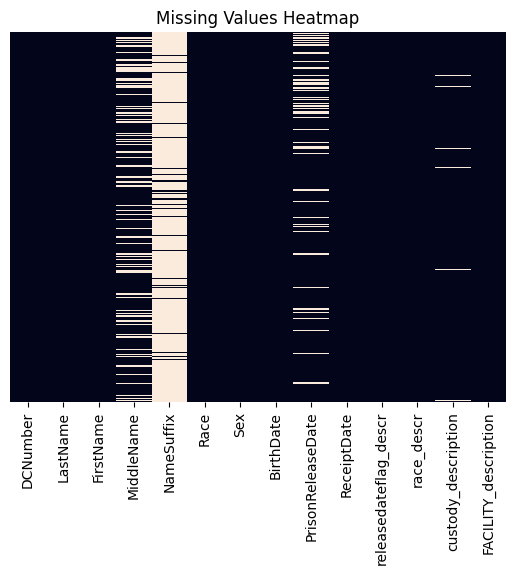

In [7]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

The columns with the most missing values are **MiddleName** and **NameSuffix**. These are not considered critical for analysis — it is common for individuals to not have a middle name on record, and name suffixes (e.g. *Jr.*, *Sr.*, *II*, *III*) are even less common. These columns will be retained but excluded from analysis.

The next most commonly missing field is **PrisonReleaseDate**. This may indicate inmates who are serving life sentences or whose release date has not yet been determined. Further investigation is needed before deciding how to handle this.

A small number of rows are also missing **custody_description**. It is unclear at this stage whether this reflects a data entry issue or a legitimate unknown classification. This will be revisited during the cleaning phase.

# Demographics

This section explores the demographic composition of Florida's active inmate population,
including age, sex, and race. Visualizations and summary statistics are provided for each.

Note: Age is calculated as of today's date based on each inmate's recorded date of birth.

In [8]:
# calculate age from birth date and add as a new column
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['Age'] = (pd.Timestamp.now() - df['BirthDate']).dt.days // 365 

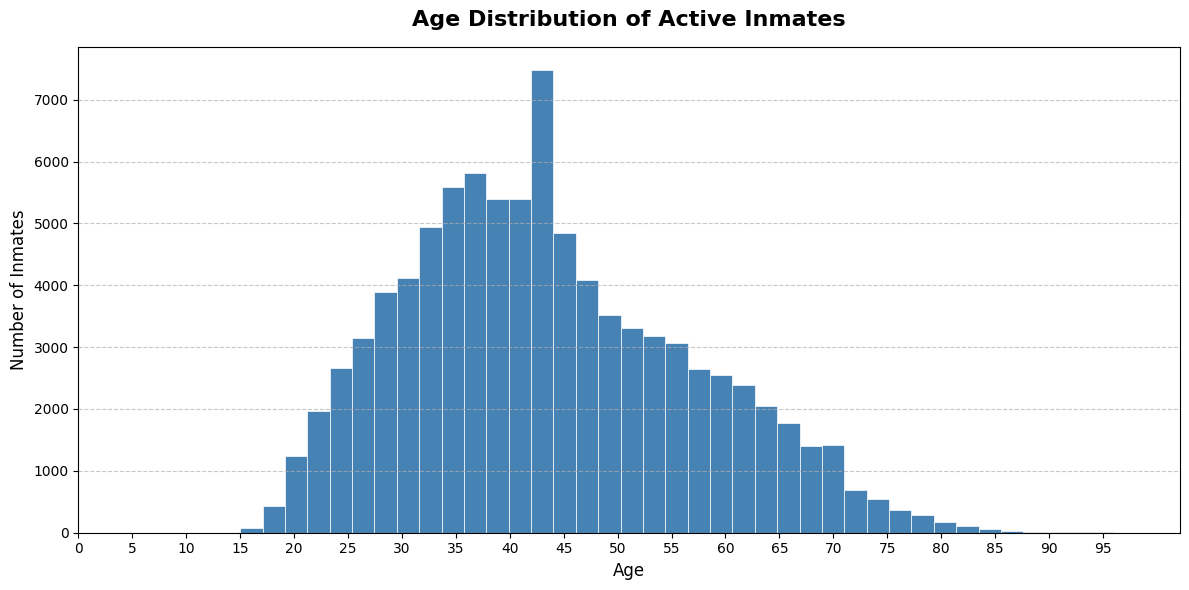

In [9]:
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Age Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
print("Age Stats:")
print(df['Age'].describe())

Age Stats:
count    90663.000000
mean        43.478641
std         13.234723
min         15.000000
25%         34.000000
50%         42.000000
75%         53.000000
max         98.000000
Name: Age, dtype: float64


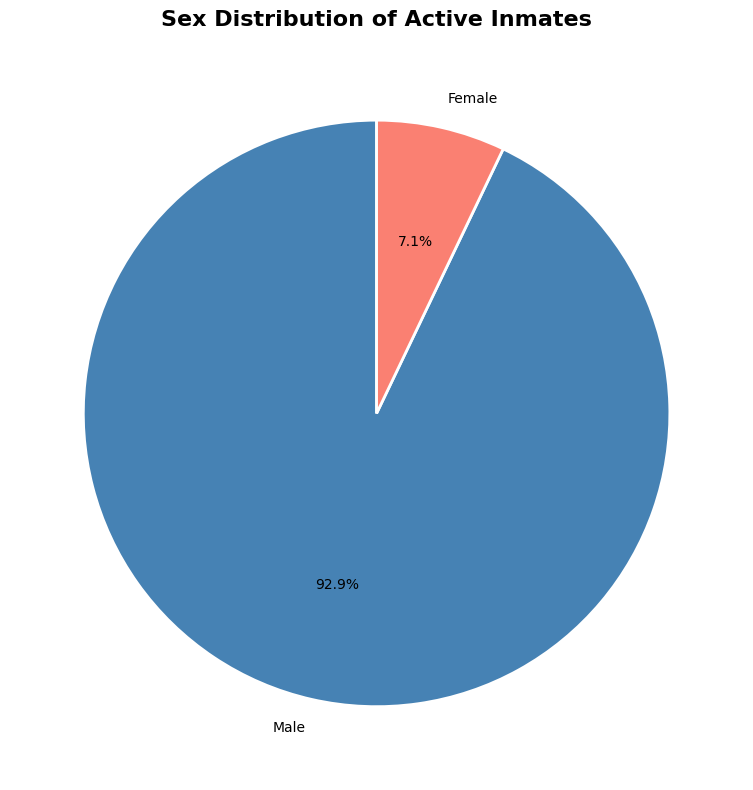

In [11]:
plt.figure(figsize=(8, 8))
sex_counts = df['Sex'].value_counts()
plt.pie(sex_counts, 
        labels=sex_counts.index.map({'M': 'Male', 'F': 'Female'}),
        autopct='%1.1f%%',
        colors=['steelblue', 'salmon'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Sex Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

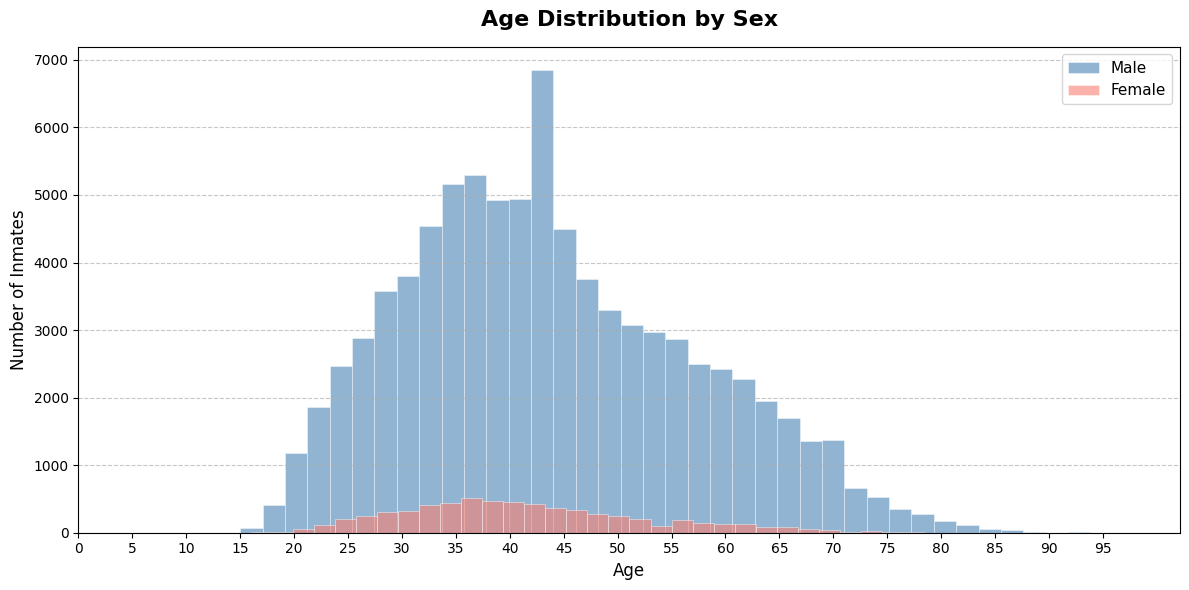

In [33]:
plt.figure(figsize=(12, 6))

male = df[df['Sex'] == 'M']['Age']
female = df[df['Sex'] == 'F']['Age']

plt.hist(male, bins=40, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.6, label='Male')
plt.hist(female, bins=40, color='salmon', edgecolor='white', linewidth=0.5, alpha=0.6, label='Female')

plt.title('Age Distribution by Sex', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
print("Male vs Female Age Stats:")
print(df.groupby('Sex')['Age'].describe())

Male vs Female Age Stats:
       count       mean        std   min   25%   50%   75%   max
Sex                                                             
F     6444.0  41.443513  11.467006  16.0  33.0  40.0  48.0  94.0
M    84219.0  43.634358  13.347637  15.0  34.0  42.0  53.0  98.0


In [14]:
df['race_descr'].unique()

array(['BLACK', 'WHITE', 'HISPANIC', 'ALL OTHERS/UNKNOWN',
       'AMERICAN INDIAN OR PACIFIC ISL', 'ASIAN OR PACIFIC ISLANDER'],
      dtype=object)

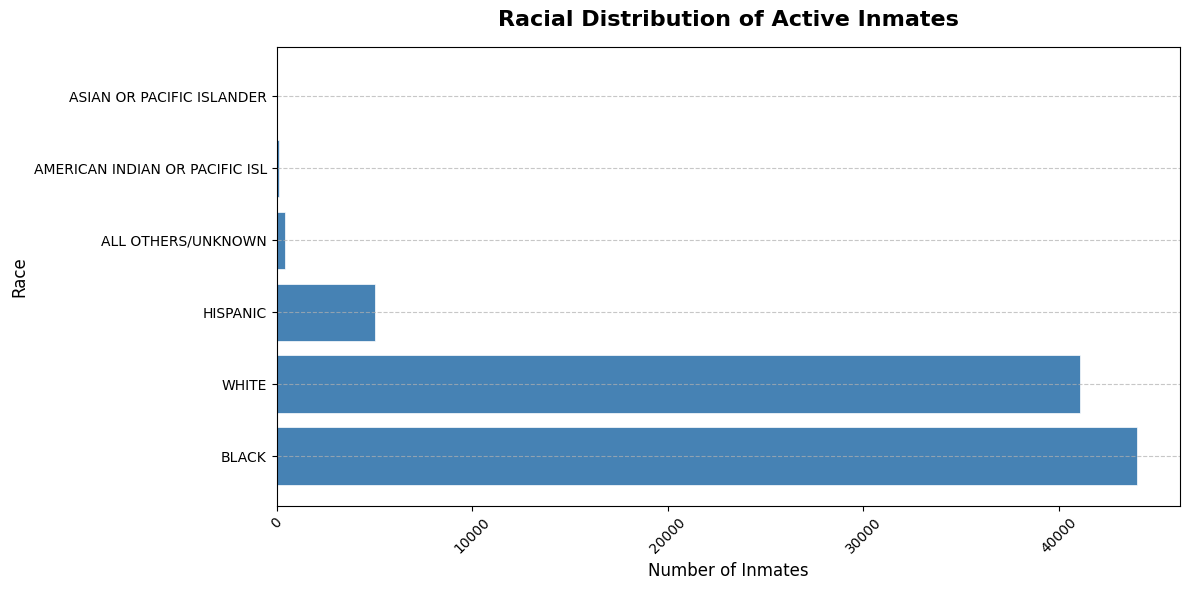

                                Count Percentage
race_descr                                      
BLACK                           44003     48.53%
WHITE                           41067      45.3%
HISPANIC                         5027      5.54%
ALL OTHERS/UNKNOWN                427      0.47%
AMERICAN INDIAN OR PACIFIC ISL    109      0.12%
ASIAN OR PACIFIC ISLANDER          30      0.03%


In [32]:
# Bar chart
race_counts = df['race_descr'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(race_counts.index, race_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Racial Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Inmates', fontsize=12)
plt.ylabel('Race', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Percentage table
race_pct = pd.DataFrame({
    'Count': race_counts,
    'Percentage': (race_counts / race_counts.sum() * 100).round(2).astype(str) + '%'
})
print(race_pct)

## Custody Levels

Inmates in the Florida DOC are assigned a custody level based on their assessed security
risk. The custody levels, from highest to lowest security, are:

- **MAXIMUM** — Highest security risk. Inmates require the most restrictive supervision
  and housing conditions.
- **CLOSE** — High security risk. Inmates are housed in secure facilities with strict
  supervision, one level below maximum.
- **MEDIUM** — Moderate security risk. Inmates are housed in standard correctional
  facilities with routine supervision.
- **MINIMUM** — Low security risk. Inmates may have more freedoms and privileges, and
  may be eligible for work release or other programs.
- **COMMUNITY** — Lowest security level. Inmates are typically in a transitional phase,
  potentially participating in community-based programs or work release in preparation
  for full reintegration.

In [16]:
# unique custody descriptions
custody_counts = df['custody_description'].value_counts()
custody_pct = pd.DataFrame({
    'Count': custody_counts,
    'Percentage': (custody_counts / custody_counts.sum() * 100).round(2).astype(str) + '%'
})
print(custody_pct)

# unique facilities
print("\nNumber of Unique Facilities: ", df['FACILITY_description'].nunique())

# ReceiptDate distribution
df['ReceiptDate'] = pd.to_datetime(df['ReceiptDate'])

                     Count Percentage
custody_description                  
CLOSE                44844     50.75%
MEDIUM               25836     29.24%
MINIMUM              12918     14.62%
COMMUNITY             4507       5.1%
MAXIMUM                253      0.29%

Number of Unique Facilities:  212


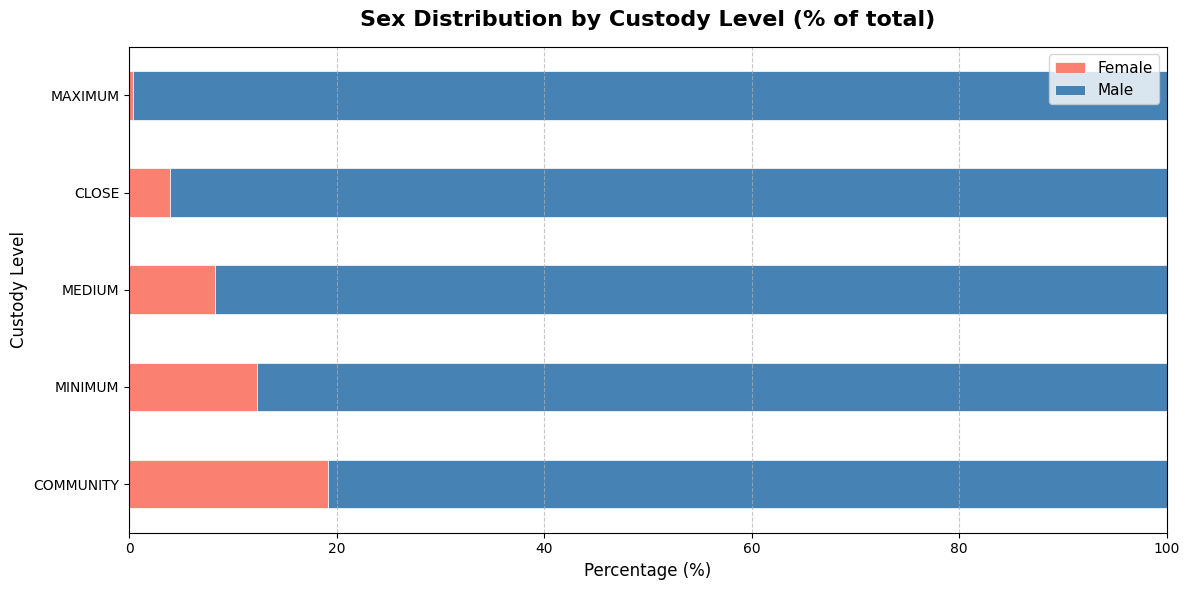

In [31]:
# Calculate counts by custody level and sex
custody_sex = df.groupby(['custody_description', 'Sex']).size().unstack(fill_value=0)

# Calculate percentages
custody_sex_pct = custody_sex.div(custody_sex.sum(axis=1), axis=0) * 100

# Reorder by security level (highest to lowest)
security_order = ['COMMUNITY', 'MINIMUM', 'MEDIUM', 'CLOSE', 'MAXIMUM']
custody_sex_pct = custody_sex_pct.reindex(security_order)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
custody_sex_pct.plot(
    kind='barh',
    stacked=True,
    color=['salmon', 'steelblue'],
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Sex Distribution by Custody Level (% of total)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Custody Level', fontsize=12)
ax.legend(['Female', 'Male'], fontsize=11)
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sex Distribution by Custody Level

This chart shows the proportion of male and female inmates at each custody level,
normalized to 100% to account for the large overall disparity in the male/female
population (~93% male, ~7% female).

By normalizing, we can ask a more interesting question: **does the male/female ratio
vary meaningfully across security levels?** The answer is yes — there is a clear pattern:
female inmates make up their largest share of the population at the COMMUNITY level, and
their representation decreases steadily as security level increases. At the highest
security levels (CLOSE, MAXIMUM), females represent a much smaller proportion of the
population than their overall share would suggest.

This indicates that female inmates in Florida's DOC tend to be classified at lower security
levels, consistent with broader national trends in corrections research.

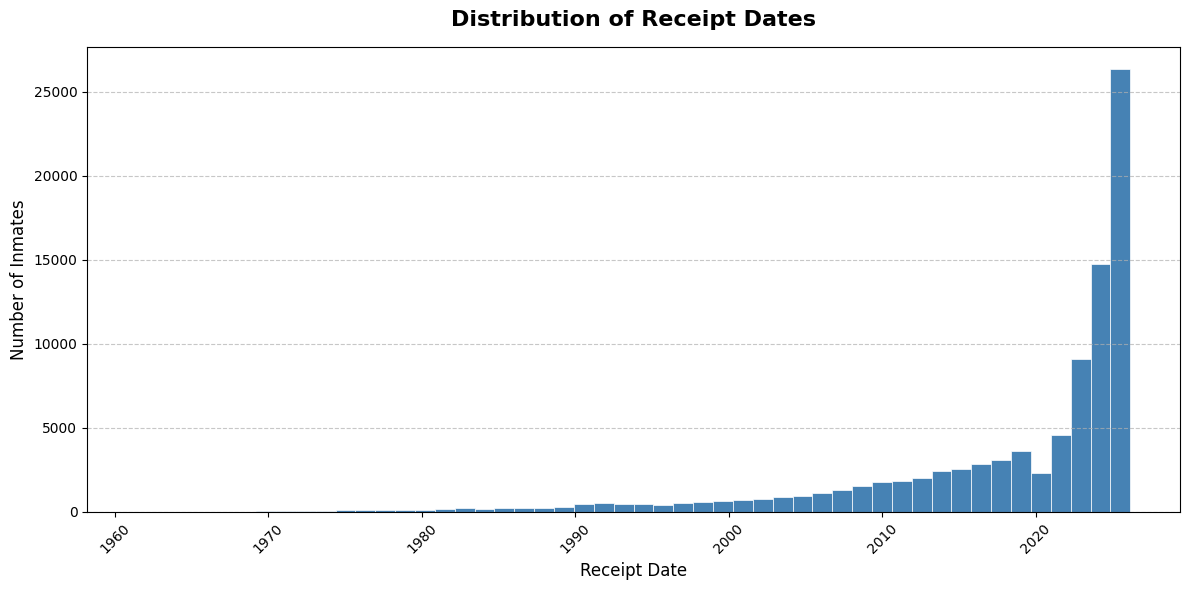

In [17]:
plt.figure(figsize=(12, 6))
plt.hist(df['ReceiptDate'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Receipt Dates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Receipt Date', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The distribution of receipt dates reveals several interesting trends in Florida's inmate population over time:

- **Pre-2005:** Admissions were slow and relatively steady.
- **2005–2020:** A noticeable and roughly linear increase in admissions, likely reflecting broader trends in criminal justice policy and  opulation growth.
- **2020:** A sharp drop in admissions, consistent with the COVID-19 pandemic, during which courts were backlogged and many jurisdictions reduced arrests and admissions.
- **Post-2020:** A dramatic spike in admissions following the pandemic drop. This may partly be due to the clearing of court backlogs rather.

This pattern is consistent with what many state prison systems experienced nationally during and after the COVID-19 pandemic. There is one important caveat to keep in mind here: the receipt dates are only for **active inmates**, meaning if an inmate was previously releasted, they wouldn't contribute any data to this figure. It's plausible that older inmates have already served time and been released. This could be another reason why more recent receipt dates are more highly represented than older dates.

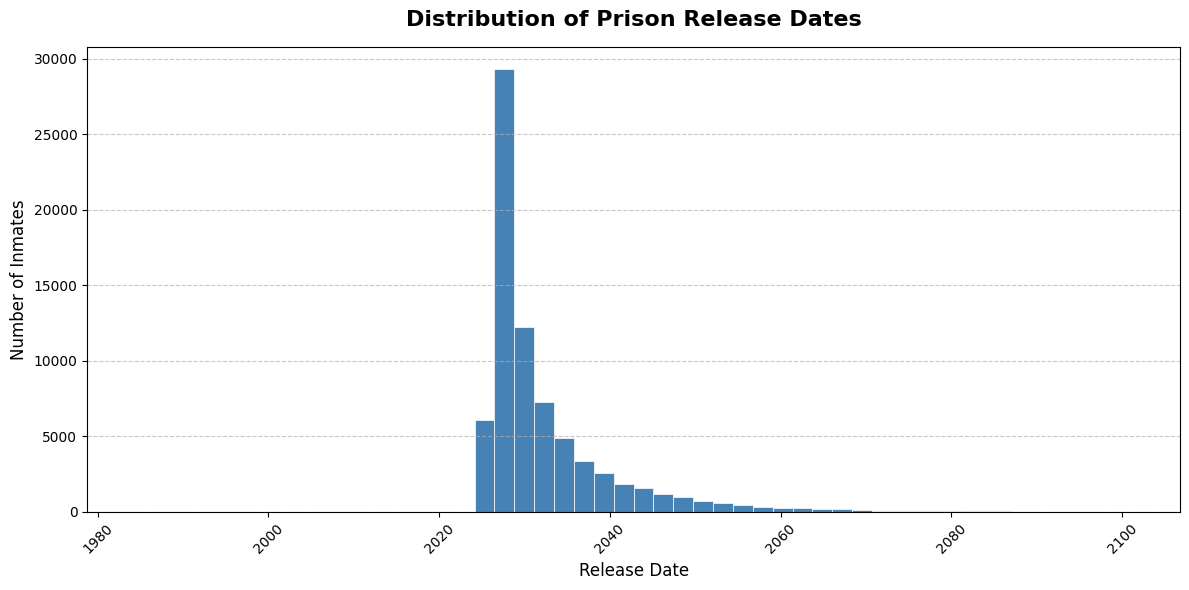

In [26]:
# drop null values; skip dates too far into the future
release_dates = df['PrisonReleaseDate'].dropna() 
release_dates = pd.to_datetime(release_dates, errors='coerce')
release_dates = release_dates[release_dates.dt.year <= 2100]  

plt.figure(figsize=(12, 6))
plt.hist(release_dates, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Prison Release Dates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Release Date', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
release_dates = df['PrisonReleaseDate'].dropna() 
release_dates = pd.to_datetime(release_dates, errors='coerce')

print("All Release Dates (including outliers):")
print(f"  Earliest: {release_dates.min()}")
print(f"  Latest:   {release_dates.max()}")
print(f"  Total with valid date: {release_dates.notna().sum()}")
print(f"  Outliers (year > 2100): {(release_dates.dt.year > 2100).sum()}")

release_dates_filtered = release_dates[release_dates.dt.year <= 2100]
print("\nFiltered Release Dates (year <= 2100):")
print(f"  Earliest: {release_dates_filtered.min()}")
print(f"  Latest:   {release_dates_filtered.max()}")
print(f"  Median:   {release_dates_filtered.median()}")
print(f"  Count:    {release_dates_filtered.count()}")

All Release Dates (including outliers):
  Earliest: 1984-08-04 00:00:00
  Latest:   2243-02-03 00:00:00
  Total with valid date: 74717
  Outliers (year > 2100): 92

Filtered Release Dates (year <= 2100):
  Earliest: 1984-08-04 00:00:00
  Latest:   2100-12-14 00:00:00
  Median:   2029-01-31 00:00:00
  Count:    74625


# Data Cleaning